# **IMPORT LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score

# **CODE HERE**

## **Data Preparation And Preprocessing**

In [2]:
# Đọc CSV
data = pd.read_csv('iot_devices.csv')

In [3]:
# Hiển thị thông tin cơ bản về dữ liệu
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   DeviceID        5000 non-null   int64  
 1   DeviceType      5000 non-null   object 
 2   ActiveHours     4900 non-null   float64
 3   PowerUsage      4900 non-null   float64
 4   Temperature     5000 non-null   float64
 5   SignalStrength  5000 non-null   float64
 6   FirmwareAge     5000 non-null   int64  
 7   Power6Months    5000 non-null   float64
 8   PowerPerHour    5000 non-null   float64
dtypes: float64(6), int64(2), object(1)
memory usage: 351.7+ KB
None


In [4]:
# Hiển thị 5 dòng đầu tiên của dữ liệu
data.head()

,DeviceID,DeviceType,ActiveHours,PowerUsage,Temperature,SignalStrength,FirmwareAge,Power6Months,PowerPerHour
0,1,Light,6.99,71.79,29.73,-46.62,43,307650.33,10.2676
1,2,Sensor,9.56,45.46,33.59,-60.82,26,195533.56,4.7574
2,3,Sensor,11.15,37.74,34.15,-61.35,30,163864.03,3.3848
3,4,Camera,13.29,50.32,17.73,-77.71,52,216855.53,3.7873
4,5,Camera,11.59,24.36,15.97,-50.38,22,104439.05,2.1014


In [5]:
# Điền giá trị thiếu của cột ActiveHours và PowerUsage bằng giá trị trung vị
data.fillna({
    'ActiveHours': data['ActiveHours'].median(),
    'PowerUsage': data['PowerUsage'].median()
}, inplace=True)

In [6]:
# Tính ma trận tương quan
corr_matrix = data.select_dtypes(include=['int64', 'float64']).corr().round(2)

# In ra kết quả
corr_matrix

,DeviceID,ActiveHours,PowerUsage,Temperature,SignalStrength,FirmwareAge,Power6Months,PowerPerHour
DeviceID,1.00,-0.02,0.02,-0.00,-0.02,-0.02,0.02,0.01
ActiveHours,-0.02,1.00,0.02,-0.02,0.00,-0.00,0.01,-0.55
PowerUsage,0.02,0.02,1.00,-0.01,0.01,0.02,0.99,0.45
Temperature,-0.00,-0.02,-0.01,1.00,-0.00,-0.01,-0.00,0.01
SignalStrength,-0.02,0.00,0.01,-0.00,1.00,-0.00,0.00,-0.00
FirmwareAge,-0.02,-0.00,0.02,-0.01,-0.00,1.00,0.02,0.01
Power6Months,0.02,0.01,0.99,-0.00,0.00,0.02,1.00,0.45
PowerPerHour,0.01,-0.55,0.45,0.01,-0.00,0.01,0.45,1.00


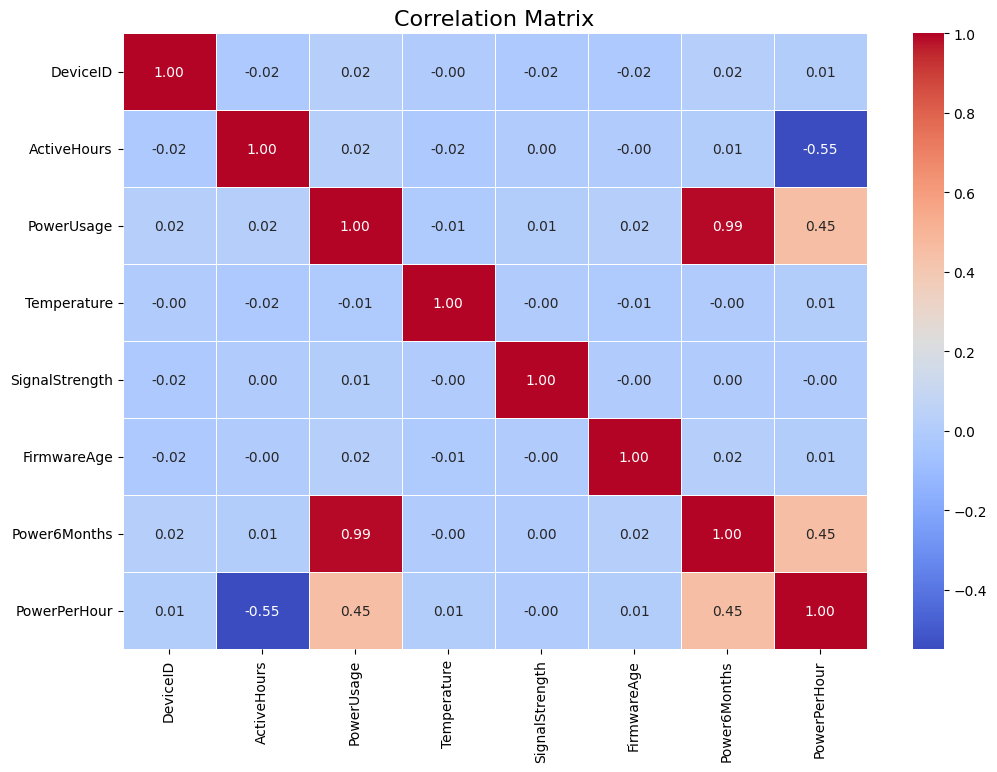

In [7]:
plt.figure(figsize=(12, 8))  # kích thước hình
sns.heatmap(corr_matrix,
            annot=True,       # hiển thị số tương quan
            cmap="coolwarm",  # bảng màu dễ nhìn
            fmt=".2f",        # format 2 chữ số thập phân
            linewidths=0.5)   # đường ngăn ô

plt.title("Correlation Matrix", fontsize=16)
plt.show()

In [8]:
corr_matrix.abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
drop_cols = [col for col in upper.columns if any(upper[col] > 0.95)]
print("Columns to drop due to high correlation:", drop_cols)

Columns to drop due to high correlation: ['Power6Months']


In [9]:
# Các cột có thuộc tính tuyến tính và không cần thiết
to_drop = ['DeviceID', 'PowerPerHour', 'Power6Months']

# Loai bỏ các cột này khỏi dữ liệu
X_train = data.drop(columns=to_drop)

In [10]:
# Các cột dạng object
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
categorical_cols

['DeviceType']

In [11]:
# Các cột dạng numeric sau khi loại bỏ
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols

['ActiveHours', 'PowerUsage', 'Temperature', 'SignalStrength', 'FirmwareAge']

In [12]:
# Tiền xử lý dữ liệu
preprocess = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]
)

## **KMeans Clustering**

In [13]:
# Xây dựng pipeline KMeans
pipe = Pipeline(steps=[
    ('prep', preprocess),
    ('kmeans', KMeans(n_clusters=5, random_state=42, n_init='auto'))
])

# Huấn luyện mô hình
pipe.fit(X_train)

# Lấy nhãn cluster sau khi huấn luyện
labels = pipe.named_steps['kmeans'].labels_

# Gán nhãn cụm vào dữ liệu gốc
data_final = X_train.copy()
data_final['Cluster'] = labels

In [14]:
# Thống kê số lượng sinh viên trong mỗi cụm
data_final['Cluster'].value_counts()

Cluster
4    1260
0    1222
2    1004
3     783
1     731
Name: count, dtype: int64

In [15]:
data_final

,DeviceType,ActiveHours,PowerUsage,Temperature,SignalStrength,FirmwareAge,Cluster
0,Light,6.99,71.79,29.73,-46.62,43,4
1,Sensor,9.56,45.46,33.59,-60.82,26,1
2,Sensor,11.15,37.74,34.15,-61.35,30,1
3,Camera,13.29,50.32,17.73,-77.71,52,2
4,Camera,11.59,24.36,15.97,-50.38,22,2
...,...,...,...,...,...,...,...
4995,Plug,11.94,73.61,40.73,-51.97,16,0
4996,Speaker,10.06,66.69,37.68,-35.04,40,3
4997,Plug,8.22,61.41,43.42,-61.45,5,0
4998,Light,13.23,52.03,46.81,-72.69,44,4


## **Evaluate The Model**

In [16]:
# Lấy dữ liệu đã được biến đổi sau tiền xử lý
X_transformed = pipe.named_steps['prep'].transform(X_train)

# Tính silhouette score
sil_score = silhouette_score(X_transformed, labels)
print(f'Silhouette Score: {sil_score:.4f}')

Silhouette Score: 0.4934


In [19]:
# Lưu thành tập tin TSV
data_final.to_csv('iot_devices_clustered.tsv', sep='\t', index=False)

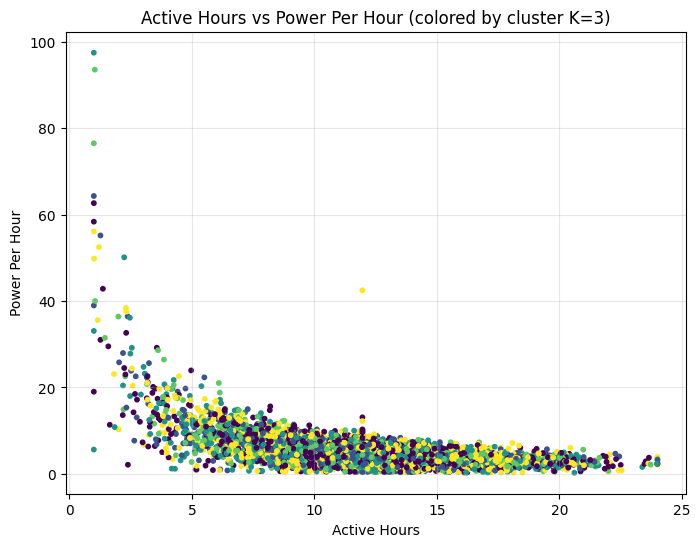

In [17]:
# Sao chép dữ liệu gốc để phân tích thêm
data_analyzed = data.copy()

# Vẽ scatter 
plt.figure(figsize=(8, 6))
plt.scatter(data_analyzed["ActiveHours"], data_analyzed["PowerPerHour"], c=data_final["Cluster"], s=10)
plt.xlabel("Active Hours")
plt.ylabel("Power Per Hour")
plt.title(f"Active Hours vs Power Per Hour (colored by cluster K=3)")
plt.grid(alpha=0.3)
plt.show()

## **Determine The Optimal Number Of Groups**

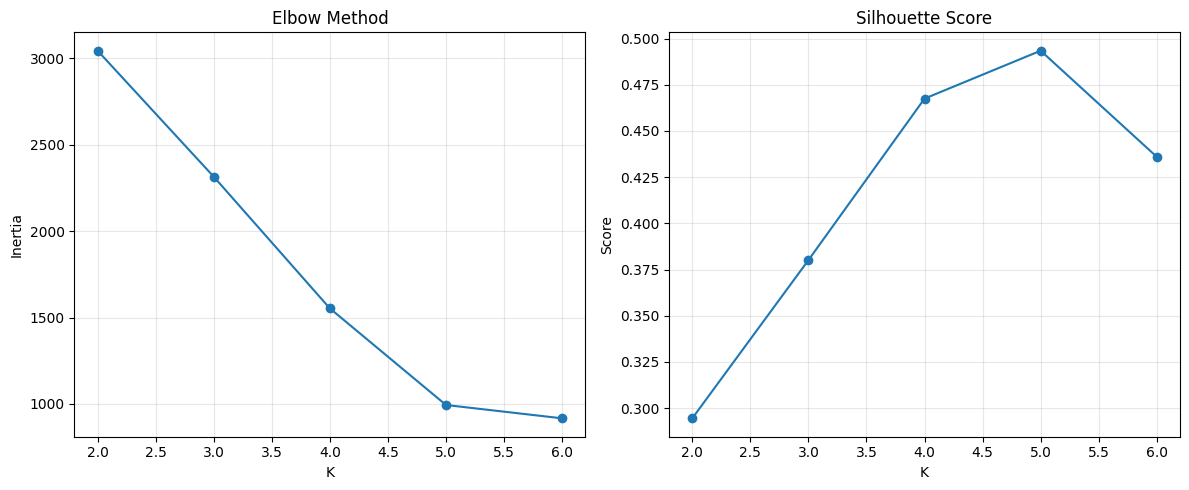

Inertia: {2: 3044.22, 3: 2314.89, 4: 1552.81, 5: 993.75, 6: 916.57}
Silhouette: {2: np.float64(0.29), 3: np.float64(0.38), 4: np.float64(0.47), 5: np.float64(0.49), 6: np.float64(0.44)}


In [18]:
inertias = []
sil_scores = []
models = {}
K_range = range(2, 7)

for k in K_range:
    preprocess = ColumnTransformer(
        transformers=[
            ('num', MinMaxScaler(), numeric_cols),
            ('cat', OneHotEncoder(drop='first'), categorical_cols)
        ]
    )
    
    pipe_k = Pipeline(steps=[
        ('prep', preprocess),
        ('kmeans', KMeans(n_clusters=k, random_state=42, n_init='auto'))
    ])
    
    labels_k = pipe_k.fit_predict(X_train)
    models[k] = pipe_k
    inertias.append(pipe_k.named_steps['kmeans'].inertia_)
    sil_scores.append(silhouette_score(pipe_k.named_steps['prep'].transform(X_train), labels_k))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(K_range, inertias, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(K_range, sil_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("K")
plt.ylabel("Score")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Inertia:", {k: round(v, 2) for k, v in zip(K_range, inertias)})
print("Silhouette:", {k: round(v, 2) for k, v in zip(K_range, sil_scores)})